In [4]:
import numpy
import scipy.special

# neural network class definition
class neuralNetwork:

    # initialise the neural network
    def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate):
        # set number of nodes in each input, hidden, output layer
        self.inodes = inputnodes
        self.hnodes = hiddennodes
        self.onodes = outputnodes
        
        # link weight matrices, wih and who
        # weights inside the arrays are w_i_j, where link is from node i to node j in the next layer
        # w11 w21
        # w12 w22 etc
        self.wih = numpy.random.normal(0.0, pow(self.hnodes, -0.5), (self.hnodes, self.inodes))
        self.who = numpy.random.normal(0.0, pow(self.onodes, -0.5), (self.onodes, self.hnodes))
        
        # learning rate
        self.lr = learningrate
        
        # activation function is the sigmoid function
        self.activation_function = lambda x: scipy.special.expit(x)
        pass

    # train the neural network
    def train(self, inputs_list, targets_list):
        # convert inputs list to 2d array
        inputs = numpy.array(inputs_list, ndmin=2).T
        targets = numpy.array(targets_list, ndmin=2).T
        
        # calculate signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)
        
        # calculate signals into final output layer
        final_inputs = numpy.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)
        
        # output layer error is the (target - actual)
        output_errors = targets - final_outputs
        
        # hidden layer error is the output_errors, split by weights, recombined at hidden nodes
        hidden_errors = numpy.dot(self.who.T, output_errors)
        
        # update the weights for the links between the hidden and output layers
        self.who += self.lr * numpy.dot((output_errors * final_outputs * (1.0 - final_outputs)), numpy.transpose(hidden_outputs))
        
        # update the weights for the links between the input and hidden layers
        self.wih += self.lr * numpy.dot((hidden_errors * hidden_outputs * (1.0 - hidden_outputs)), numpy.transpose(inputs))
        pass

    # query the neural network
    def query(self, inputs_list):
        # convert inputs list to 2d array
        inputs = numpy.array(inputs_list, ndmin=2).T
        
        # calculate signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)
        
        # calculate signals into final output layer
        final_inputs = numpy.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)
        
        return final_outputs

✅ Image automatically saved as 'matrix_plot.png'


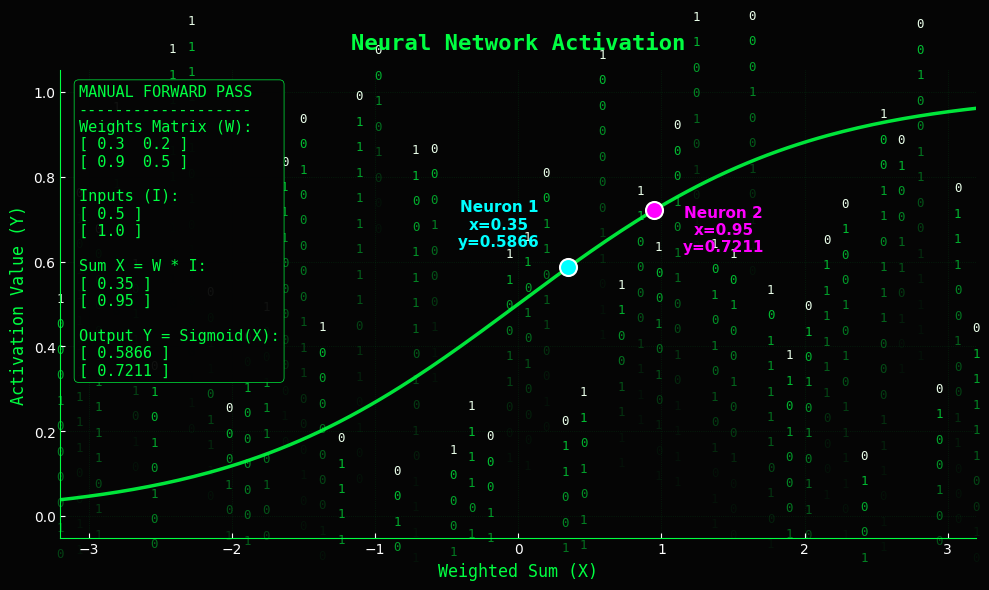

In [12]:
import numpy as np
import scipy.special
import matplotlib.pyplot as plt

# 1. Manual parameters from my notebook
wih = np.array([[0.3, 0.2], 
                [0.9, 0.5]])
inputs = np.array([[0.5], 
                   [1.0]])

# 2. Forward pass calculation
hidden_inputs = np.dot(wih, inputs)
hidden_outputs = scipy.special.expit(hidden_inputs)

# 3. Setup beautiful dark theme plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#050505') # Deep black background
ax.set_facecolor('#050505')

# --- TRUE MATRIX BACKGROUND EFFECT ---
np.random.seed(42) # For reproducible rain
# Create columns of falling text
for x_pos in np.linspace(-3.2, 3.2, 50): # 50 columns
    y_start = np.random.uniform(0.1, 1.2) # Random start height for each stream
    stream_length = np.random.randint(8, 20)
    
    for i in range(stream_length):
        y_pos = y_start - (i * 0.06)
        if y_pos < -0.1: break
            
        char = str(np.random.randint(0, 2))
        
        # The "head" of the stream is bright, the tail fades out
        if i == 0:
            color = '#eaffea' # Bright almost-white green for the tip
            alpha = 1.0
        else:
            color = '#00ff41' # Classic matrix green
            alpha = max(0.05, 0.8 - (i / stream_length))
            
        ax.text(x_pos, y_pos, char, color=color, alpha=alpha, 
                fontsize=9, fontfamily='monospace', 
                ha='center', va='center', zorder=1)

# 4. Plot the Sigmoid curve
x_vals = np.linspace(-3.5, 3.5, 200)
y_vals = scipy.special.expit(x_vals)
ax.plot(x_vals, y_vals, color='#00ff41', linewidth=2.5, zorder=3, alpha=0.9)

# 5. Plot specific calculated points
color_n1 = '#00ffff' # Neon Cyan 
color_n2 = '#ff00ff' # Neon Magenta 

ax.scatter(hidden_inputs[0][0], hidden_outputs[0][0], color=color_n1, s=150, zorder=5, edgecolors='white', linewidth=1.5)
ax.scatter(hidden_inputs[1][0], hidden_outputs[1][0], color=color_n2, s=150, zorder=5, edgecolors='white', linewidth=1.5)

ax.annotate(f'Neuron 1\nx={hidden_inputs[0][0]:.2f}\ny={hidden_outputs[0][0]:.4f}', 
            (hidden_inputs[0][0], hidden_outputs[0][0]), textcoords="offset points", xytext=(-50, 15), 
            ha='center', color=color_n1, fontsize=11, fontweight='bold', zorder=6)

ax.annotate(f'Neuron 2\nx={hidden_inputs[1][0]:.2f}\ny={hidden_outputs[1][0]:.4f}', 
            (hidden_inputs[1][0], hidden_outputs[1][0]), textcoords="offset points", xytext=(50, -30), 
            ha='center', color=color_n2, fontsize=11, fontweight='bold', zorder=6)

# 6. Add Matrix Information Box
info_text = (
    "MANUAL FORWARD PASS\n"
    "-------------------\n"
    "Weights Matrix (W):\n"
    "[ 0.3  0.2 ]\n"
    "[ 0.9  0.5 ]\n\n"
    "Inputs (I):\n"
    "[ 0.5 ]\n"
    "[ 1.0 ]\n\n"
    "Sum X = W * I:\n"
    f"[ {hidden_inputs[0][0]:.2f} ]\n"
    f"[ {hidden_inputs[1][0]:.2f} ]\n\n"
    "Output Y = Sigmoid(X):\n"
    f"[ {hidden_outputs[0][0]:.4f} ]\n"
    f"[ {hidden_outputs[1][0]:.4f} ]"
)

# Dark solid background for the text box so the matrix rain doesn't make it unreadable
props = dict(boxstyle='round', facecolor='#050505', alpha=0.95, edgecolor='#00ff41')
ax.text(0.02, 0.97, info_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', color='#00ff41', fontfamily='monospace', bbox=props, zorder=7)

# 7. Final grid and styling touches
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.05, 1.05)
ax.grid(color='#00ff41', linestyle=':', alpha=0.15, zorder=2)
ax.set_title('Neural Network Activation', color='#00ff41', fontsize=16, pad=15, fontweight='bold', fontfamily='monospace')
ax.set_xlabel('Weighted Sum (X)', color='#00ff41', fontsize=12, fontfamily='monospace')
ax.set_ylabel('Activation Value (Y)', color='#00ff41', fontsize=12, fontfamily='monospace')
ax.spines['bottom'].set_color('#00ff41')
ax.spines['left'].set_color('#00ff41')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# --- AUTO SAVE FUNCTION ---
plt.savefig('matrix_plot.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print("✅ Image automatically saved as 'matrix_plot.png'")

plt.show()